In [1]:
import numpy as np

from IPython.display import Image

# Valid Convolution, Circular Convolution, and Overlap-Add methods <br>for Sliding Dot Product!

The sliding dot product of a query, `Q`, and a time series, `T`, is an array of length `len(T) - len(Q) + 1`, where the $i^{th}$ element is the dot product between `Q` and `T[i:i+len(Q)]`. This is equivalent to the `valid convolution` between `T` and `Q_flip`, where `Q_flip` is the flip (reverse) of `Q`.

## Valid Convolution

The `valid convolution` between two arrays is computed by flipping the shorter array and sliding it along the longer array, and compute the dot product when there is a full overlap. Therefore the sliding dot product between `T` and `Q` is equivalent to the valid convolution between `T` and  `Q_flip`. Note that we said `Q_flip` in convolution. This is because the convolution process flips the array (before sliding it across the longer array `T`), and therefore it changes the array back to `Q`.

**Example:**
<br> 
Suppose `T = [1, 2, 3, 4, 5]` and `Q = [1, 2, 3]`. Their sliding dot product is `[14, 20, 26]`. Recall that this is equivalent to the valid convolution between `T = [1, 2, 3, 4, 5]` and `Q_flip = [3, 2, 1]`.

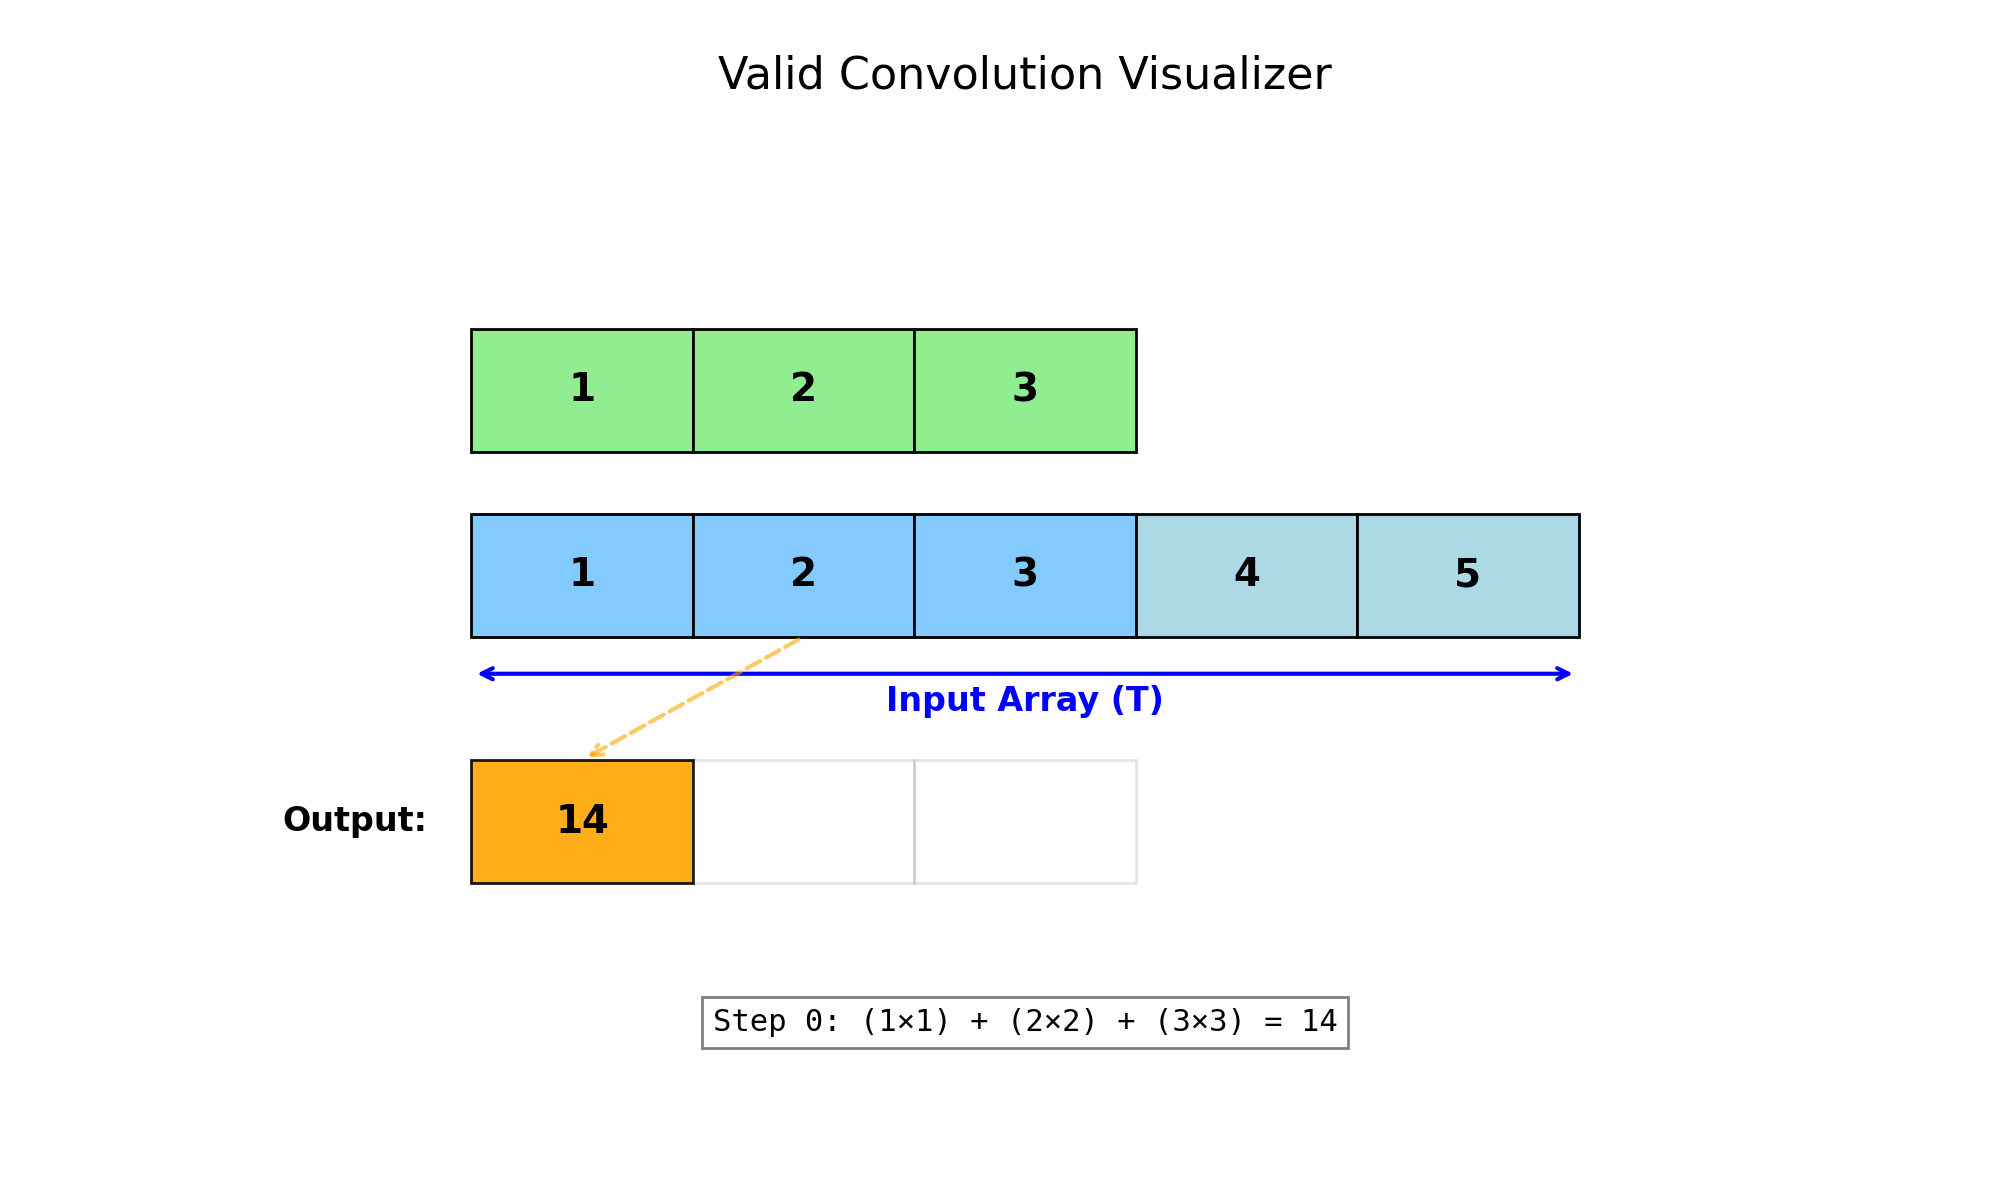

In [3]:
Image(filename='valid_convolution.gif')

The time complexity of convolution via flip-and-slide form is $O(nm)$, where `n=len(T)` and `m=len(Q)`. For large arrays, this can be computed faster with the help of `FFT`, which comes to the picture in `circular convolution`. 

## Circular Convolution

The circular convolution is [defined as the convolution between two periodic sequences that have the same period](https://en.wikipedia.org/wiki/Circular_convolution). The output will also be a periodic sequence with the same period as inputs'. Let's revisit our example from previous section. The circular convolution between `T = [1, 2, 3, 4, 5]` and `Q_flip=[3, 2, 1]` can be computed as follows:

* pad `Q_flip` with zeros till its length becomes the same as the longer array `T`: `Q_flip_paded = [3, 2, 1, 0, 0]`
* Compute the convolution between `T` and `Q_flip_paded` by:
  * Flip the array `Q_flip_paded`
  * Slide the flipped array across `T` starting from where there is at least one overlapping element
  * For other elements of a sequence, its corresponding element from the other sequence can be obtained since sequences are periodic

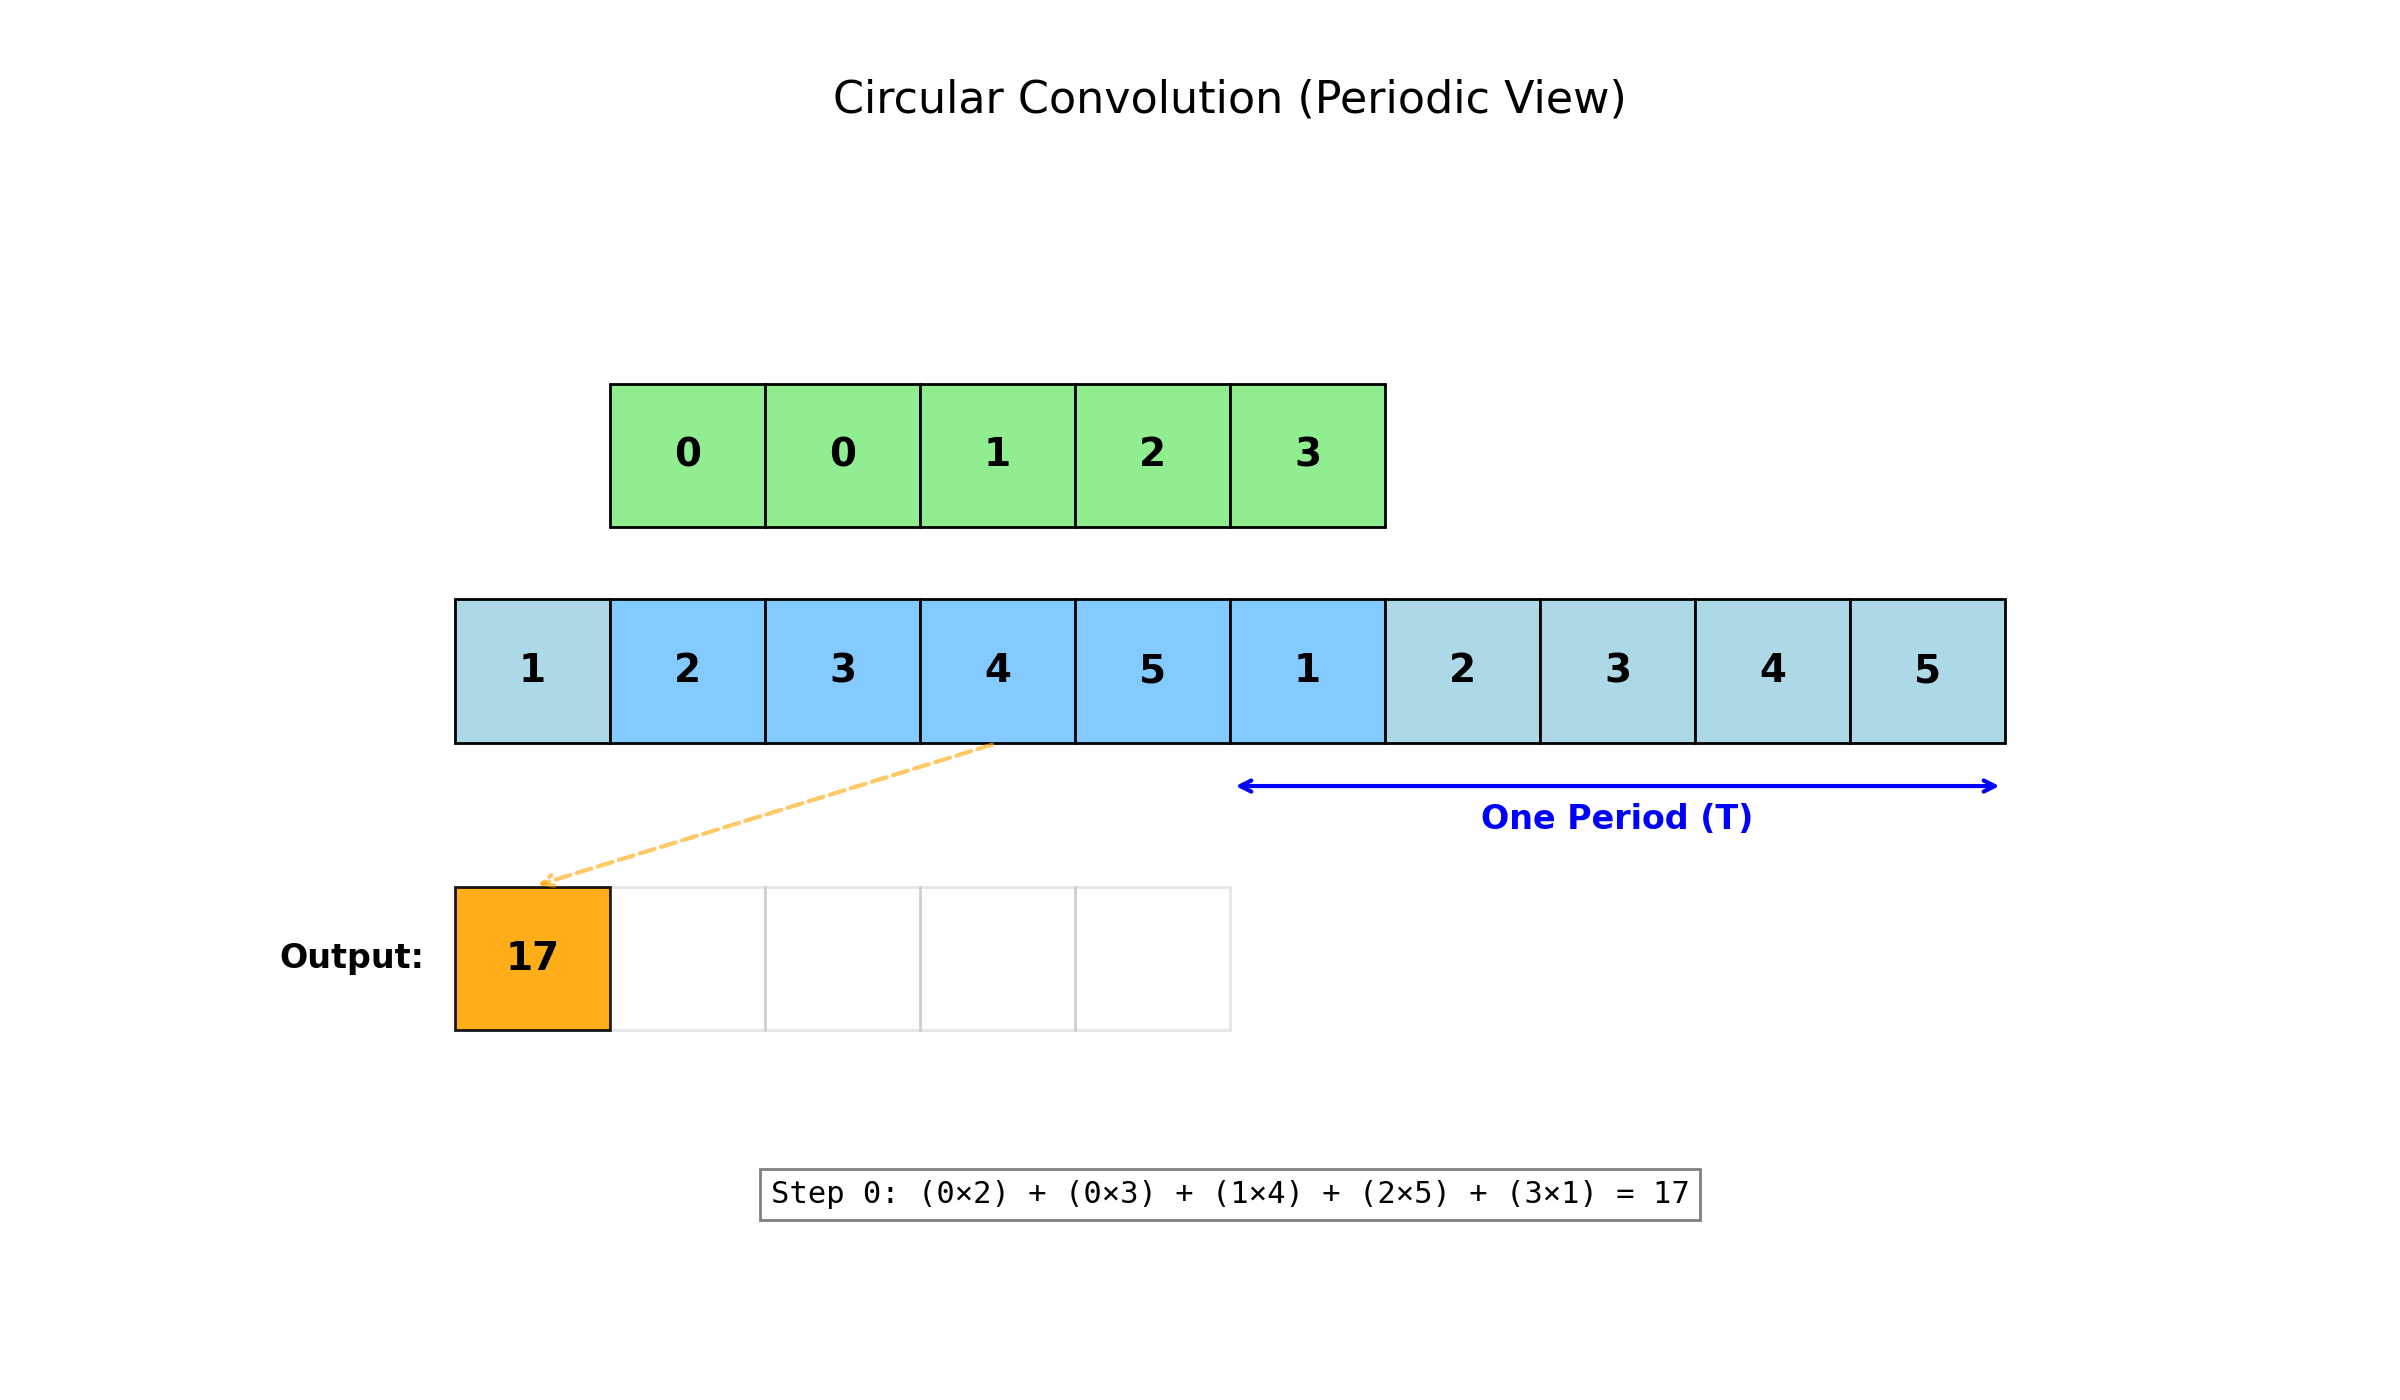

In [4]:
Image(filename='convolution_annotated_circular.gif')

Note that `slice(2, 5)` of output is the same as the valid convolution computed before! So, we can calculate the sliding dot product using circular convolution, and get the slice in `range(2, 5)`. The animation above shows the circular convolution in time domain. This can be computed in frequency domain as follows:
<br> 
`IFFT( FFT(T) * FFT(Q_flip_paded) )`

In [4]:
T = np.array([1, 2, 3, 4, 5]).astype(np.float64)
Q_flip_paded = np.array([3, 2, 1, 0, 0]).astype(np.float64)

out = np.fft.ifft(np.fft.fft(T) * np.fft.fft(Q_flip_paded))
out

array([17.+0.j, 13.+0.j, 14.+0.j, 20.+0.j, 26.+0.j])

and we can get the sliding dot product using `out.real[2:5]`, which gives the expected value `[14, 20, 26]`

## 6. Overlap-add Convolution

So far, we learned that we can use FFT-based circular convolution to compute the sliding dot product between `Q` and `T`, and it should be faster for longer arrays. It turns out that there is a way to achieve the valid convolution on large arrays by performing several circular convolutions on chunks of the arrays. [overlap-add method](https://en.wikipedia.org/wiki/Overlap–add_method) is one of the common approaches. This can make the computation faster if the chunk size is chosen properly. For now, we do not care about the optimal size of the chunk, and we simply would like to show how this method works.

**Example:**
<br>
`T = [1, 2, 3, ..., 10]` and `Q = [1, 2, 3]`.  Their sliding dot product is `[14, 20, 26, 32, 38, 44, 50, 56]`. Recall that our goal is to compute the valid convolution between `T` and `Q_flip`, which is `[3, 2, 1]`. In circular convolution, we pad `Q_flip` with zero till its length becomes the same as `len(T)`. In overlap-add method, we first chunk `T` into smaller arrays. For instance, let's consider chunksize of `C=5`. Therefore, `T` can be chunked to `T1=[1, 2, 3, 4, 5]` and `T2=[6, 7, 8, 9, 10]`. We now pad `Q_flip` and each chunk with zeros till the length of each chunk becomes equal to `C + len(Q) - 1`. Finally, we calculate the circular convolution between padded chunk and padded `Q_flip`, and combine the outputs at the end. 

* T1_padded = [1, 2, 3, 4, 5, 0, 0]
* T2_padded = [6, 7, 8, 9, 10, 0, 0]
* Q_flip_padded = [3, 2, 1, 0, 0, 0, 0]

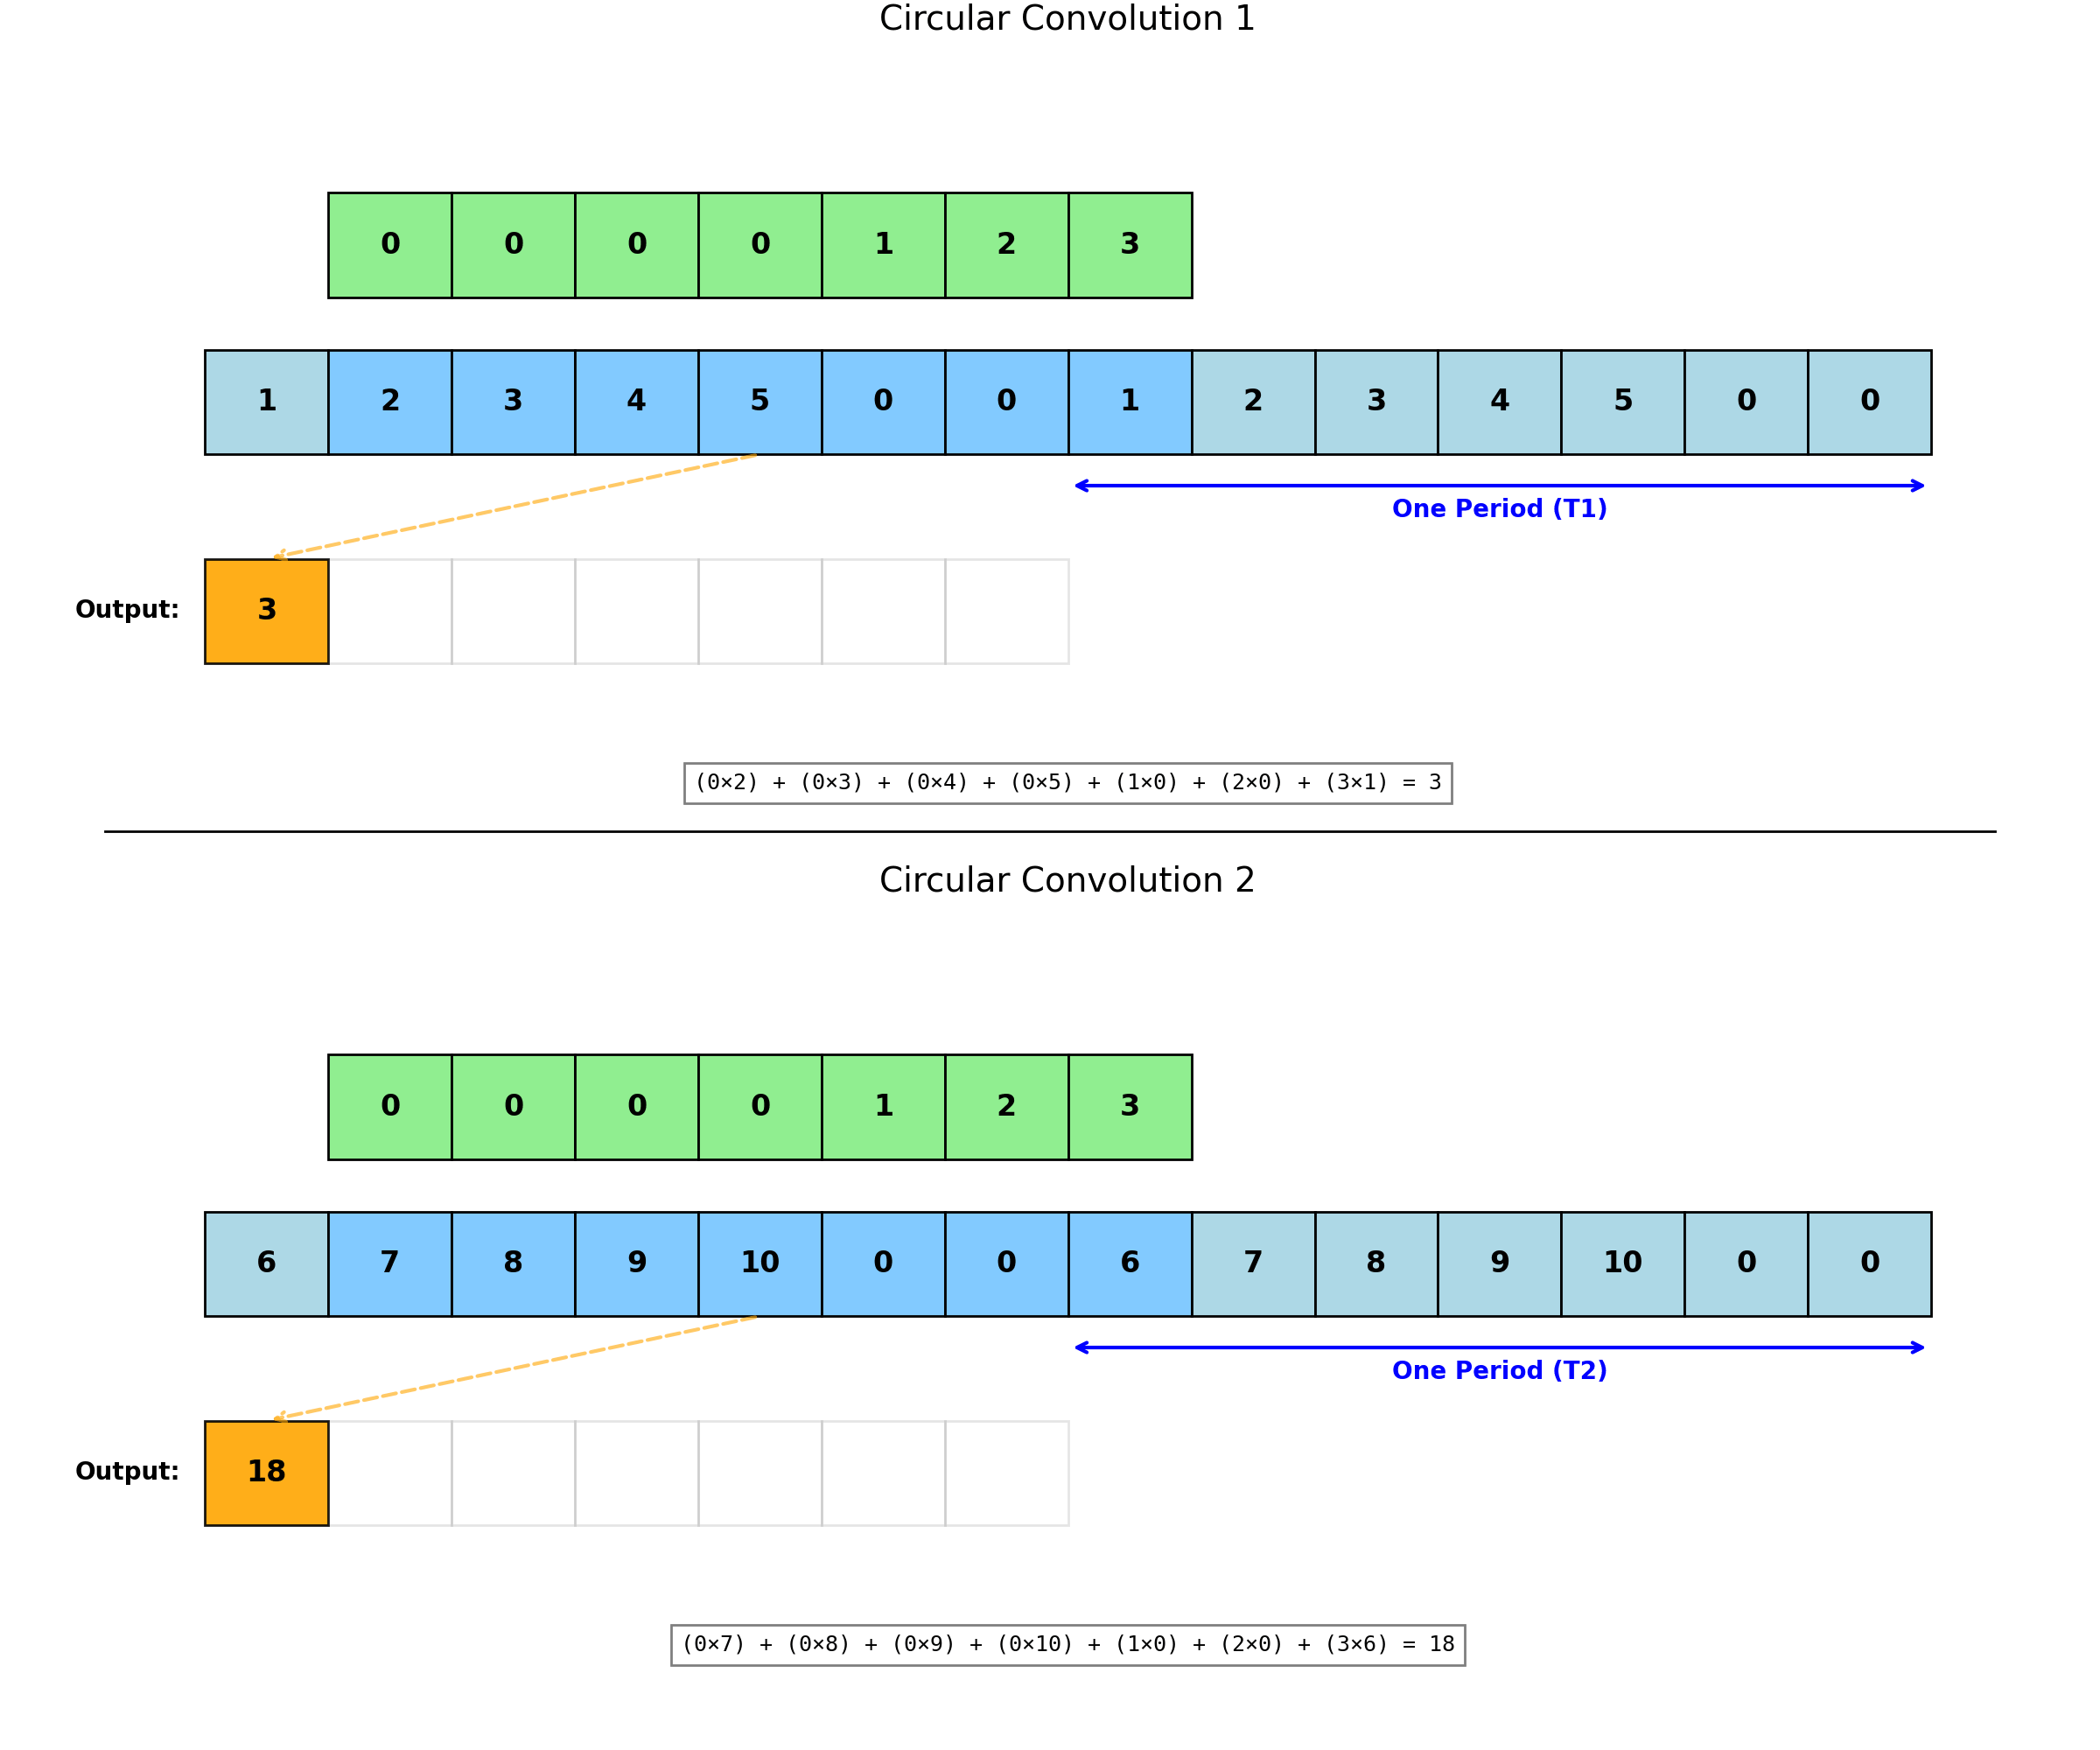

In [3]:
Image(filename='dual_convolution.gif')

Once the circular convoluton between each padded chunk and padded `Q_flip` is computed, we can combine the outputs by adding the `m-1` elements at the tail of the first output to the `m-1` elements at the head of the second output. This is because chunking `T` into smaller arrays results in losing the subsequences `[4, 5, 6]`, and `[5, 6, 7]`, and therefore we need to add the tail of the first output to the head of the second output to recover the dot product between `Q` and those lost subsequences. 

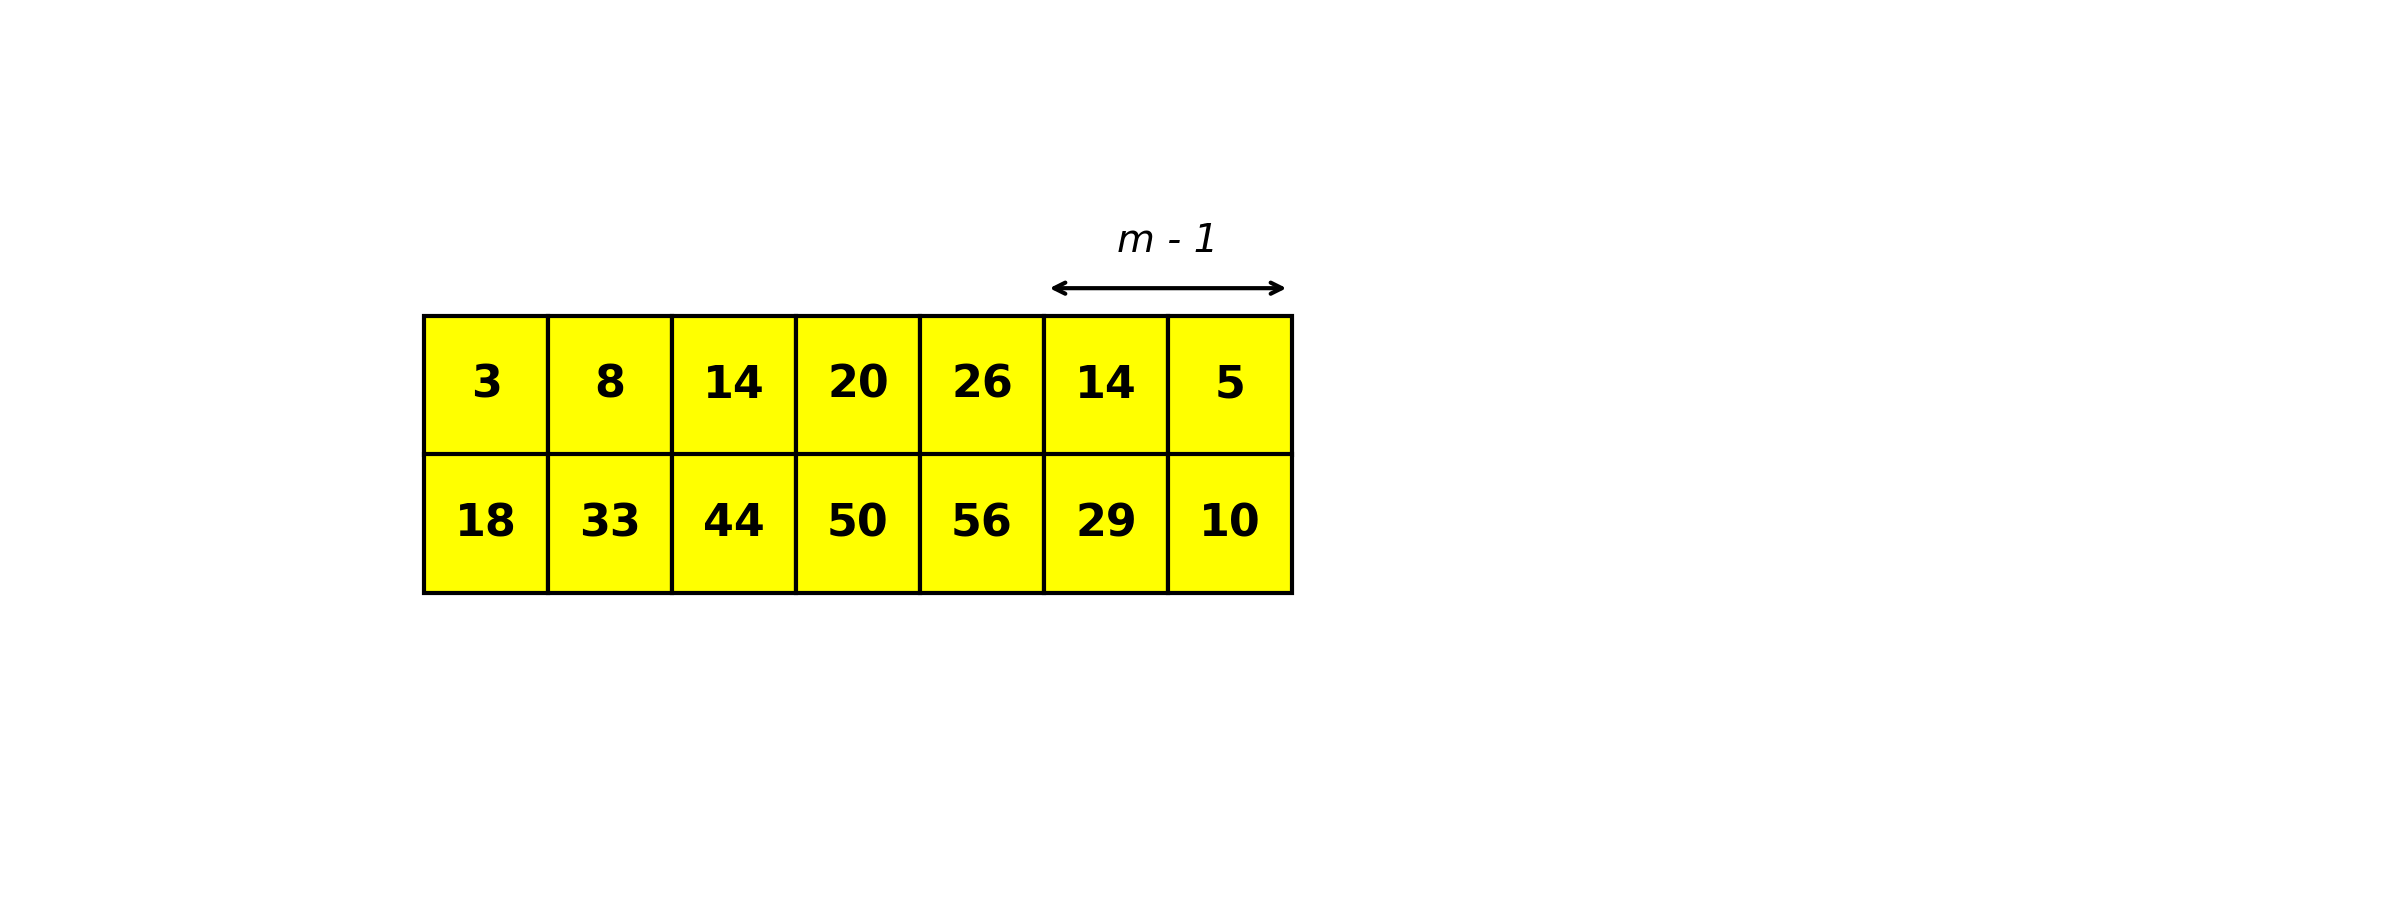

In [8]:
Image(filename='array_merge_annotated.gif')

Let's verify the result by computing the valid convolution between `T` and `Q_flip` directly.

In [7]:
T = np.arange(1, 11).astype(np.float64)
Q_flip = np.array([3, 2, 1]).astype(np.float64)

np.convolve(T, Q_flip, mode='valid')

array([14., 20., 26., 32., 38., 44., 50., 56.])